In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydataset import data

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [25]:
# Load Dataset
usarrests = data("USArrests")

usarrests.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [26]:
print(usarrests.info())

print("\nMissing Values")
print(usarrests.isnull().sum())

print("\nSummary Statistics")
print(usarrests.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB
None

Missing Values
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

Summary Statistics
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000


In [27]:
# Standardize the Dataset
scaler = StandardScaler()

scaled_data = scaler.fit_transform(usarrests)

In [28]:
variances = pd.DataFrame(
    scaled_data,
    columns=usarrests.columns
).var()

print(variances.sort_values(ascending=False))

Murder      1.020408
Assault     1.020408
UrbanPop    1.020408
Rape        1.020408
dtype: float64


In [29]:
# Feature Selection
selected_features = usarrests[["Murder","Assault","Rape"]]

In [30]:
# Standardize Selected Features
selected_scaled = scaler.fit_transform(selected_features)

In [31]:
# PCA /2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(selected_scaled)

print(pca.explained_variance_ratio_)

print("Total Variance:", pca.explained_variance_ratio_.sum())

[0.7861934  0.15268378]
Total Variance: 0.9388771782627572


PCA successfully reduced the selected crime variables to two principal components while retaining approximately 93.9% of the original information. This indicates that the two-dimensional representation provides an accurate summary of the underlying crime patterns and is suitable for visualization and clustering.

In [32]:
# Elbow Method
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    inertia.append(model.inertia_)

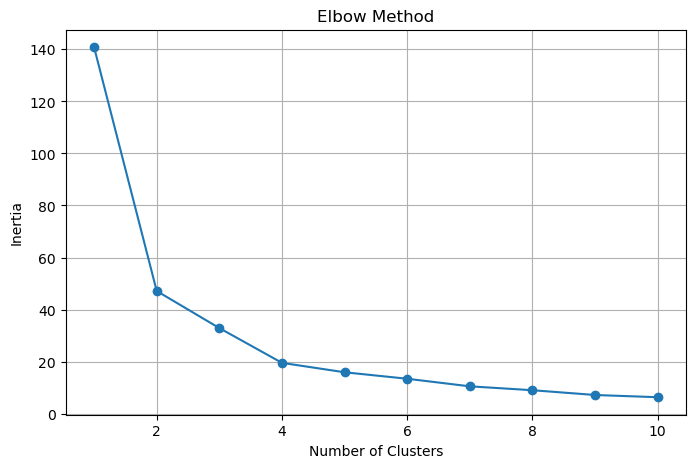

In [54]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
# Bayesian Information Criterion (BIC) for GMM
bic = []

for k in range(1,11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_pca)

    bic.append(gmm.bic(X_pca))

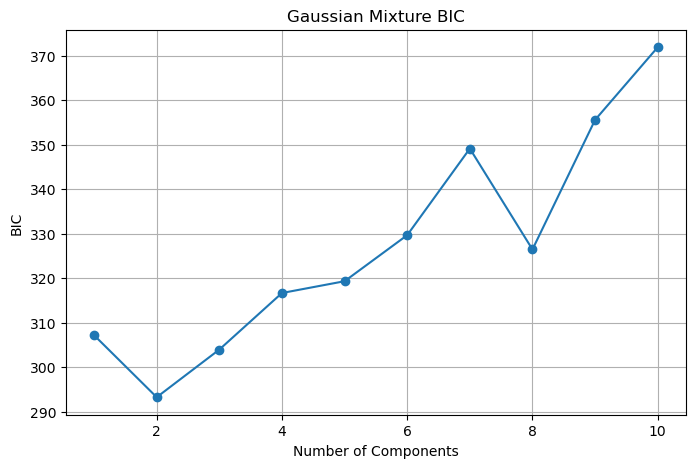

In [53]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), bic, marker="o")

plt.xlabel("Number of Components")

plt.ylabel("BIC")

plt.title("Gaussian Mixture BIC")

plt.grid(True)

plt.savefig("../images/bic_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
# K-Means Clustering
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

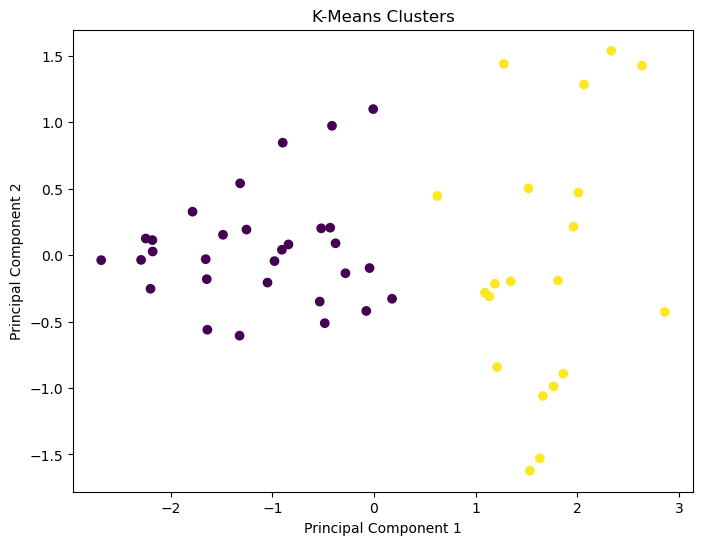

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters")

plt.savefig("../images/kmeans_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
# GMM Clustering
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)

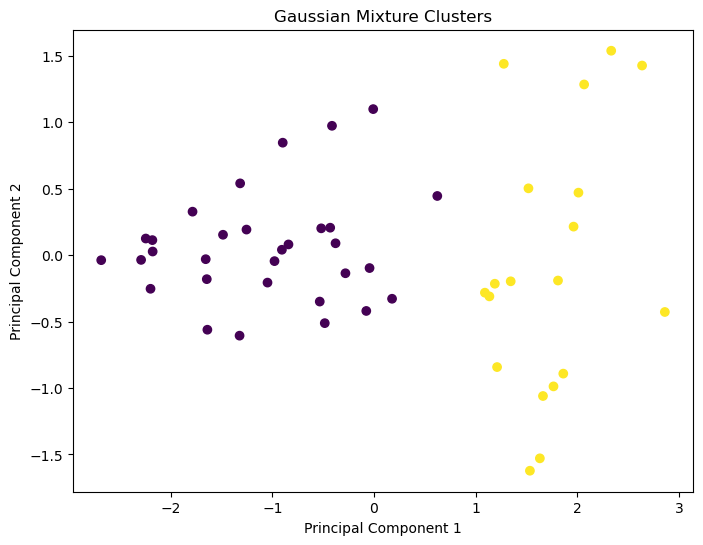

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Gaussian Mixture Clusters")

plt.savefig("../images/gmm_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
# Compare Cluster Sizes

print("K-Means")

print(pd.Series(kmeans_labels).value_counts())

print()

print("Gaussian Mixture")

print(pd.Series(gmm_labels).value_counts())

K-Means
0    30
1    20
Name: count, dtype: int64

Gaussian Mixture
0    31
1    19
Name: count, dtype: int64


In [45]:
cluster_results = usarrests.copy()
cluster_results["Cluster"] = kmeans_labels

print(cluster_results.groupby("Cluster").mean())

         Murder     Assault   UrbanPop       Rape
Cluster                                          
0         4.870  114.433333  63.633333  15.943333
1        12.165  255.250000  68.400000  29.165000


In [46]:
cluster_results = usarrests.copy()

cluster_results["KMeans_Cluster"] = kmeans_labels
cluster_results["GMM_Cluster"] = gmm_labels

cluster_results.head()

,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster
Alabama,13.2,236,58,21.2,1,1
Alaska,10.0,263,48,44.5,1,1
Arizona,8.1,294,80,31.0,1,1
Arkansas,8.8,190,50,19.5,0,0
California,9.0,276,91,40.6,1,1


In [47]:
print("States in K-Means Cluster 0:\n")

print(cluster_results[cluster_results["KMeans_Cluster"] == 0].index.tolist())

States in K-Means Cluster 0:

['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [48]:
print("States in K-Means Cluster 1:\n")

print(cluster_results[cluster_results["KMeans_Cluster"] == 1].index.tolist())

States in K-Means Cluster 1:

['Alabama', 'Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Missouri', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']


In [49]:
for cluster in sorted(cluster_results["GMM_Cluster"].unique()):
    print(f"\nGMM Cluster {cluster}")
    print(cluster_results[cluster_results["GMM_Cluster"] == cluster].index.tolist())


GMM Cluster 0
['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Missouri', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

GMM Cluster 1
['Alabama', 'Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']


In [50]:
cluster_results[["KMeans_Cluster", "GMM_Cluster"]].sort_values("KMeans_Cluster")

,KMeans_Cluster,GMM_Cluster
Wyoming,0,0
Oklahoma,0,0
New Jersey,0,0
New Hampshire,0,0
Oregon,0,0
Nebraska,0,0
Montana,0,0
Wisconsin,0,0
Pennsylvania,0,0
Minnesota,0,0


## Analysis
The clustering analysis successfully grouped the states into two distinct clusters based on their violent crime statistics. After standardizing the data, selecting relevant features, and reducing the dimensionality with PCA (retaining 93.89% of the original variance), both the Elbow Method and the Bayesian Information Criterion identified two as the optimal number of clusters. K-Means and Gaussian Mixture Models produced very similar groupings, separating states into a lower-crime cluster and a higher-crime cluster. These findings provide a clear, data-driven basis for developing targeted public safety policies and allocating resources according to the crime profiles of different regions.